# (노트) DNN (2) 
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [딥러닝]

### About this doc 

`-` 2021년 데이터과학 강의노트

### 확률적 경사하강법 

`-` $loss=(\frac{1}{2}\beta-1)^2$를 최소하는 $\beta$를 컴퓨터를 활용하여 구하는 문제를 생각해보자. (우리는 답을 알고 있긴 함 $\beta=2$)

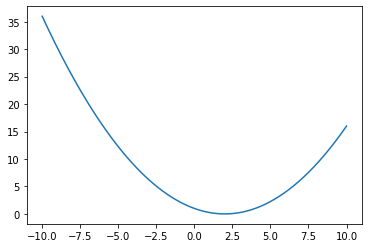

In [8]:
import numpy as np 
beta=np.linspace(-10,10,1000)
loss=(beta*0.5-1)**2
import matplotlib.pyplot as plt 
plt.plot(beta,loss)

#### 방법1: grid search

***[알고리즘1]*** 

(1) $[-10,-9.99, \dots, 9.99, 10]$와 같은 수열을 만든다. 

(2) $(-10/2-1)^2, (-9.99/2-1)^2, \dots, (9.99/2-1)^2, (10/2-1)^2)$를 계산한다. 

(3) 2의 결과를 가자 작게 만드는 값을  $(-10,-9.99, \dots, 9.99, 10)$ 에서 고른다. 

`-` 비판1: $[-10,10]$ 이외에 해가 존재하면? 이 예제의 경우는 운좋게 $[-10,10]$에서 해가 존재했지만 임의의 고정된 $x,y$에 대하여 

$$
loss(\beta)=(x\beta-y)^2
$$

의 형태의 해가 항상 $[-10,10]$에서 존재한다는 보장은 없음. 

`-` 비판2: 효율적이지 않음. 알고리즘을 요약하면 결국 -10부터 10까지 작은 간격으로 조금씩 이동하며 loss를 조사하는 것이 grid search의 아이디어인데 생각해보니까 $\beta=2$인 순간 $loss=(\frac{1}{2}\beta-1)^2=0$이 되어서 이것보다 작은 최소값은 존재하지 않는다(제곱은 항상 양수이어야 하므로). 따라서 $\beta=2$ 이후로는 탐색할 필요가 없다. 

#### 방법2: gradient descent

***[알고리즘2]*** 

(1) 임의의 초기값을 선정하고 loss를 계산한다. 
 - $\beta=-5 \to loss(-5)=(-5/2-1)^2=12.25$

(2) 임의의 초기값에서 좌우로 약간씩 이동해보고 loss를 계산한다.
 - 왼쪽으로 이동: $\beta=-5.01,\quad loss(5.01)=12.285025$
 - 오른쪽으로 이동: $\beta=-4.99, \quad loss(-4.99)=12.215025$ 

(3) (2)의 결과를 보고 어느쪽으로 이동하는것이 유리한지 따져보고 `유리한 방향으로` 이동한다. 
 - $\beta=-4.99$ 로 이동 
 
(4) (2)-(3) 의 과정을 반복한다. 왼쪽/오른쪽 모두 가봐도 유리한 지점이 없다면 알고리즘을 멈춘다. 

`-` 알고리즘이 멈추는 지점은 $\beta=2$이다. 왜냐하면 이경우 왼쪽으로 가도, 오른쪽으로 가도 현재 손실함수값보다 크기 때문. 

`-` 이 알고리즘은 $loss=(x\beta-y)^2$의 꼴에서 $[-10,10]$ 이외의 지점에 해가 존재하여도 적절하게 해를 찾을것 이다. 

`-` 또한 비효율적으로 $\beta=2$ 이후에도 탐색을 반복하지 않는다. 

`-` 알고리즘에서 (2)의 과정은 손실함수에 미분을 하는 과정으로 볼 수 있고 (3)의 과정은 미분계수를 해석하여 손실함수를 줄이는 쪽으로 조금씩 $\beta$를 update하는 것으로 볼 수 있다. 이처럼 손실함수의 기울기(=경사)를 계산하여 점차적으로 가중치를 업데이트 하는 방식을 경사하강법이라고 부른다. 

`-` 현재 알고리즘에서는 

### XOR 문제란?!

`-` XOR이란? 

|$x_1$|$x_2$|$y=x_1\oplus x_2$|
|:-:|:-:|:-:|
|$0$|$0$|$0$|
|$0$|$1$|$1$|
|$1$|$0$|$1$|
|$1$|$1$|$0$|

In [1]:
x1=[0,0,1,1]
x2=[0,1,0,1]
y=[0,1,1,0]

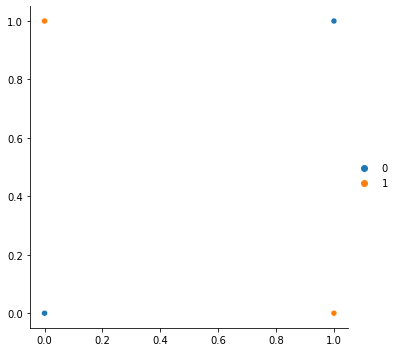

In [3]:
import pandas as pd
import seaborn as sns
df=pd.DataFrame({'x1':x1,'x2':x2,'y':y})
sns.relplot(data=df,x=x1,y=x2,hue=y)

`-` 목표: $x_1,x_2$를 입력으로 받고 $y$를 출력하는 신경망을 만들어보자. 

### XOR 문제의 해법

#### 은닉층이 0개일 경우

`-` 만들수 없다. (활성화 함수는 non-decreasing 이므로) 